# 05 — Clustering, PCA & Network

**Goal:** do unverified reviews split into distinguishable *styles* (generic praise vs. detailed)? K-means on TF-IDF + PCA + hierarchical views; plus a product-reviewer network to surface suspicious product clusters.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config()
utils.set_seeds(config["project"]["random_seed"])
viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src import fallback_loader as fl, clean
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
assert cats, "No data in data/raw/. Download a category (see notebook 01 / README)."
print("categories present:", cats)
df = clean.clean_reviews(pd.concat(
    [pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
print("reviews:", len(df), "| verified rate:", round((df["verified_purchase"] == True).mean(), 3))

categories present: ['Subscription_Boxes']
2026-06-08 17:38:30,481 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-08 17:38:30,636 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


reviews: 16216 | verified rate: 0.88


In [3]:
from src import models, features, network
feat = features.build_feature_table(df, config)
X = models.design_matrix(feat)
print("design matrix:", X.shape)

2026-06-08 17:38:34,954 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


design matrix: (16216, 28)


### PCA of review features, colored by the proxy label

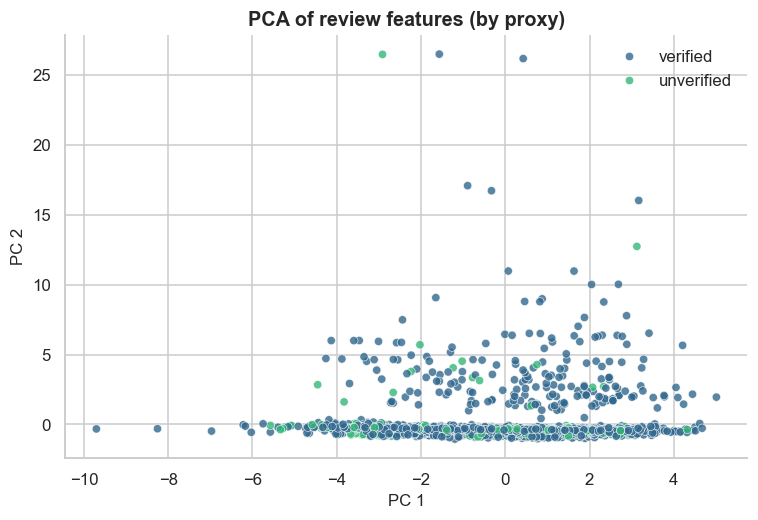

In [4]:
pipe, coords = models.fit_pca(X, 2)
pos = np.sort(np.random.default_rng(42).choice(len(X), size=min(2000, len(X)), replace=False))
labels = df["verified_purchase"].map({True:"verified",False:"unverified"}).fillna("unknown").to_numpy()[pos]
ax = viz.plot_pca_scatter(coords[pos], labels=labels, title="PCA of review features (by proxy)")
viz.savefig(ax, str(FIG/"05_pca.png")); plt.show()

### Review-style clusters (TF-IDF → SVD → K-means)

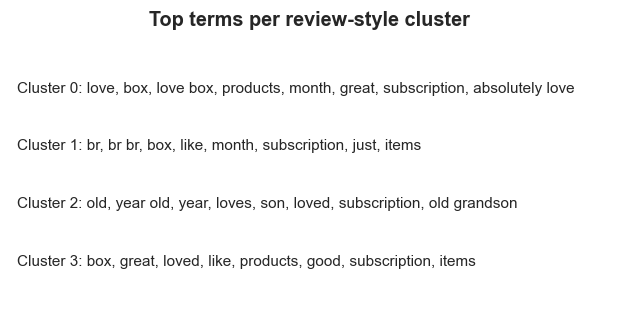

0 ['love', 'box', 'love box', 'products', 'month', 'great', 'subscription', 'absolutely love']
1 ['br', 'br br', 'box', 'like', 'month', 'subscription', 'just', 'items']
2 ['old', 'year old', 'year', 'loves', 'son', 'loved', 'subscription', 'old grandson']
3 ['box', 'great', 'loved', 'like', 'products', 'good', 'subscription', 'items']


In [5]:
clabels, top_terms, vec = models.cluster_review_styles(df, config, n_clusters=4)
ax = viz.plot_top_terms(top_terms); viz.savefig(ax, str(FIG/"05_style_terms.png")); plt.show()
for k, terms in top_terms.items():
    print(k, terms[:8])

### Hierarchical structure (dendrogram on a sample)

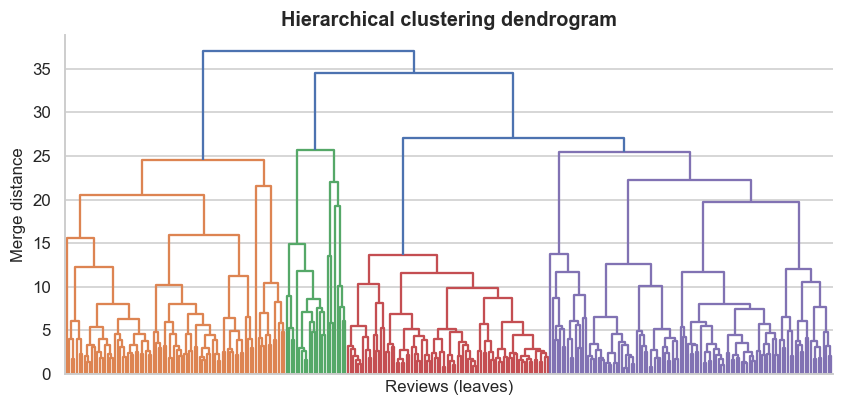

In [6]:
sub = np.sort(np.random.default_rng(0).choice(len(X), size=min(300, len(X)), replace=False))
Z = models.linkage_matrix(X.iloc[sub])
ax = viz.plot_dendrogram(Z); viz.savefig(ax, str(FIG/"05_dendrogram.png")); plt.show()

### Suspicious products (unsupervised network signal)
Products ranked by a z-scored blend of low verified-rate + review burst + near-duplicate text + shared-reviewer degree. A *candidate* ranking, not a verdict.

In [7]:
sus = network.suspicious_product_table(df, config)
print(sus.head(10).round(3).to_string())

            review_count  verified_ratio  mean_rating  burst_max  mean_near_dup  n_reviewers  shared_reviewer_degree  community  suspicion_score
product_id                                                                                                                                      
B07DNLTBG7          1177           0.849        3.565         80          0.410         1158                      23          0           32.516
B07N1572VL          1772           0.951        3.760         26          0.396         1753                      19          1           19.010
B07VBB4GLM           572           0.589        4.421         55          0.327          567                       4          2           14.326
B09WC47S3V           782           0.936        3.857         37          0.356          773                       6          1           11.408
B08N5QKX1Y           478           0.772        3.400         37          0.317          477                       3          1   

**Findings.** Name the styles from the cluster terms above; relate the top suspicious products back to the proxy and (notebook 07) the real label.